# Ciência de Dados : Inteligência Artificial e Previsões

## Score de Crédito dos Clientes

Definir o score de crédito dos clientes com base em análise, cria um modelo que consiga ler as informações do cliente e dizer automaticamente o score de crédito dele: Poor , Good, Standard 

In [21]:
import pandas as pd

df = pd.read_csv('clientes.csv')

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  str    
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  str    
 13  divida_total              100000 non-null  float64
 14  

In [22]:
# Label encoding para converter strings em numeros
#%pip install scikit-learn
from sklearn.preprocessing import LabelEncoder

# Profissão
codificador_profissao = LabelEncoder()
df['profissao'] = codificador_profissao.fit_transform(df['profissao'])

# mix_credito
codificador_mix_credito = LabelEncoder()
df['mix_credito'] = codificador_mix_credito.fit_transform(df['mix_credito'])

# comportamento_pagamento
codificador_comportamento_pagamento = LabelEncoder()
df['comportamento_pagamento'] = codificador_comportamento_pagamento.fit_transform(df['comportamento_pagamento'])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id_cliente                100000 non-null  int64  
 1   mes                       100000 non-null  int64  
 2   idade                     100000 non-null  float64
 3   profissao                 100000 non-null  int64  
 4   salario_anual             100000 non-null  float64
 5   num_contas                100000 non-null  float64
 6   num_cartoes               100000 non-null  float64
 7   juros_emprestimo          100000 non-null  float64
 8   num_emprestimos           100000 non-null  float64
 9   dias_atraso               100000 non-null  float64
 10  num_pagamentos_atrasados  100000 non-null  float64
 11  num_verificacoes_credito  100000 non-null  float64
 12  mix_credito               100000 non-null  int64  
 13  divida_total              100000 non-null  float64
 14  

In [23]:
# Separação entre variáveis independentes (x) e variável dependente (y)
x = df.drop(columns=['id_cliente', 'score_credito'])
y = df['score_credito']

from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

In [24]:
# Arvore de Decisão -> RandomForest
# Nearest Neighbors -> KNN -> Vizinhos Próximos

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#modelo_arvore_decisao = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=100, n_jobs=-1)
modelo_arvore_decisao = RandomForestClassifier()
modelo_vizinhos_proximos = KNeighborsClassifier()

modelo_arvore_decisao.fit(x_treino, y_treino)
modelo_vizinhos_proximos.fit(x_treino, y_treino)

previsoes_arvore_decisao = modelo_arvore_decisao.predict(x_teste)
previsoes_vizinhos_proximos = modelo_vizinhos_proximos.predict(x_teste)

In [25]:
# Escolher qual o melhor modelo 
# acurácia

from sklearn.metrics import accuracy_score

print(f"Acuracia de Árvore de Decisão: {accuracy_score(y_teste, previsoes_arvore_decisao)*100:.2f}%")
print(f"Acuracia de Vizinhos Próximos: {accuracy_score(y_teste, previsoes_vizinhos_proximos)*100:.2f}%")

Acuracia de Árvore de Decisão: 82.30%
Acuracia de Vizinhos Próximos: 73.69%


## Ajustes de Hiperparâmetros, no caso aqui RandomForestClassifier

### Verifica qual o melhor parâmetro para obter o melhor resultado de previsão
No caso aqui: "max_depth" , "n_estimators"

Não colocar parâmetros obteve o melhor resultado:
. modelo_arvore_decisao = RandomForestClassifier()
. obteve: Acuracia de Árvore de Decisão: 82.51 %

Com parêmtros obteve o resultado:
. Acuracia de Árvore de Decisão: 72.71 %


In [27]:
# Verificar o melhor parâmetro para o modelo de Árvore de Decisão usando GridSearchCV

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings("ignore")

param_grid = {
    "max_depth": [None,5, 10],
    "n_estimators": [None, 50, 100]
}

grid = GridSearchCV(XGBClassifier(eval_metric="logloss"),
                    param_grid,
                    cv=3,
                    n_jobs=-1,
                    scoring="recall")

# Codificar em números o retorno de y_treino[1 , 2, 3] porque ele retorna[Good, Poor, Standard]
y_treino_encode = LabelEncoder()
y_treino_encode = y_treino_encode.fit_transform(y_treino)

grid.fit(x_treino, y_treino_encode)

print("O Melhor Parâmetro",grid.best_params_)

O Melhor Parâmetro {'max_depth': None, 'n_estimators': None}


In [28]:
from sklearn.metrics import classification_report

print("Relatório de Classificação - Árvore de Decisão:")
print(classification_report(y_teste, previsoes_arvore_decisao), "\n")
print("Relatório de Classificação - Vizinhos Próximos:")
print(classification_report(y_teste, previsoes_vizinhos_proximos))

Relatório de Classificação - Árvore de Decisão:
              precision    recall  f1-score   support

        Good       0.80      0.78      0.79      5322
        Poor       0.81      0.84      0.82      8805
    Standard       0.84      0.83      0.83     15873

    accuracy                           0.82     30000
   macro avg       0.81      0.82      0.82     30000
weighted avg       0.82      0.82      0.82     30000
 

Relatório de Classificação - Vizinhos Próximos:
              precision    recall  f1-score   support

        Good       0.63      0.63      0.63      5322
        Poor       0.74      0.77      0.76      8805
    Standard       0.77      0.75      0.76     15873

    accuracy                           0.74     30000
   macro avg       0.71      0.72      0.72     30000
weighted avg       0.74      0.74      0.74     30000



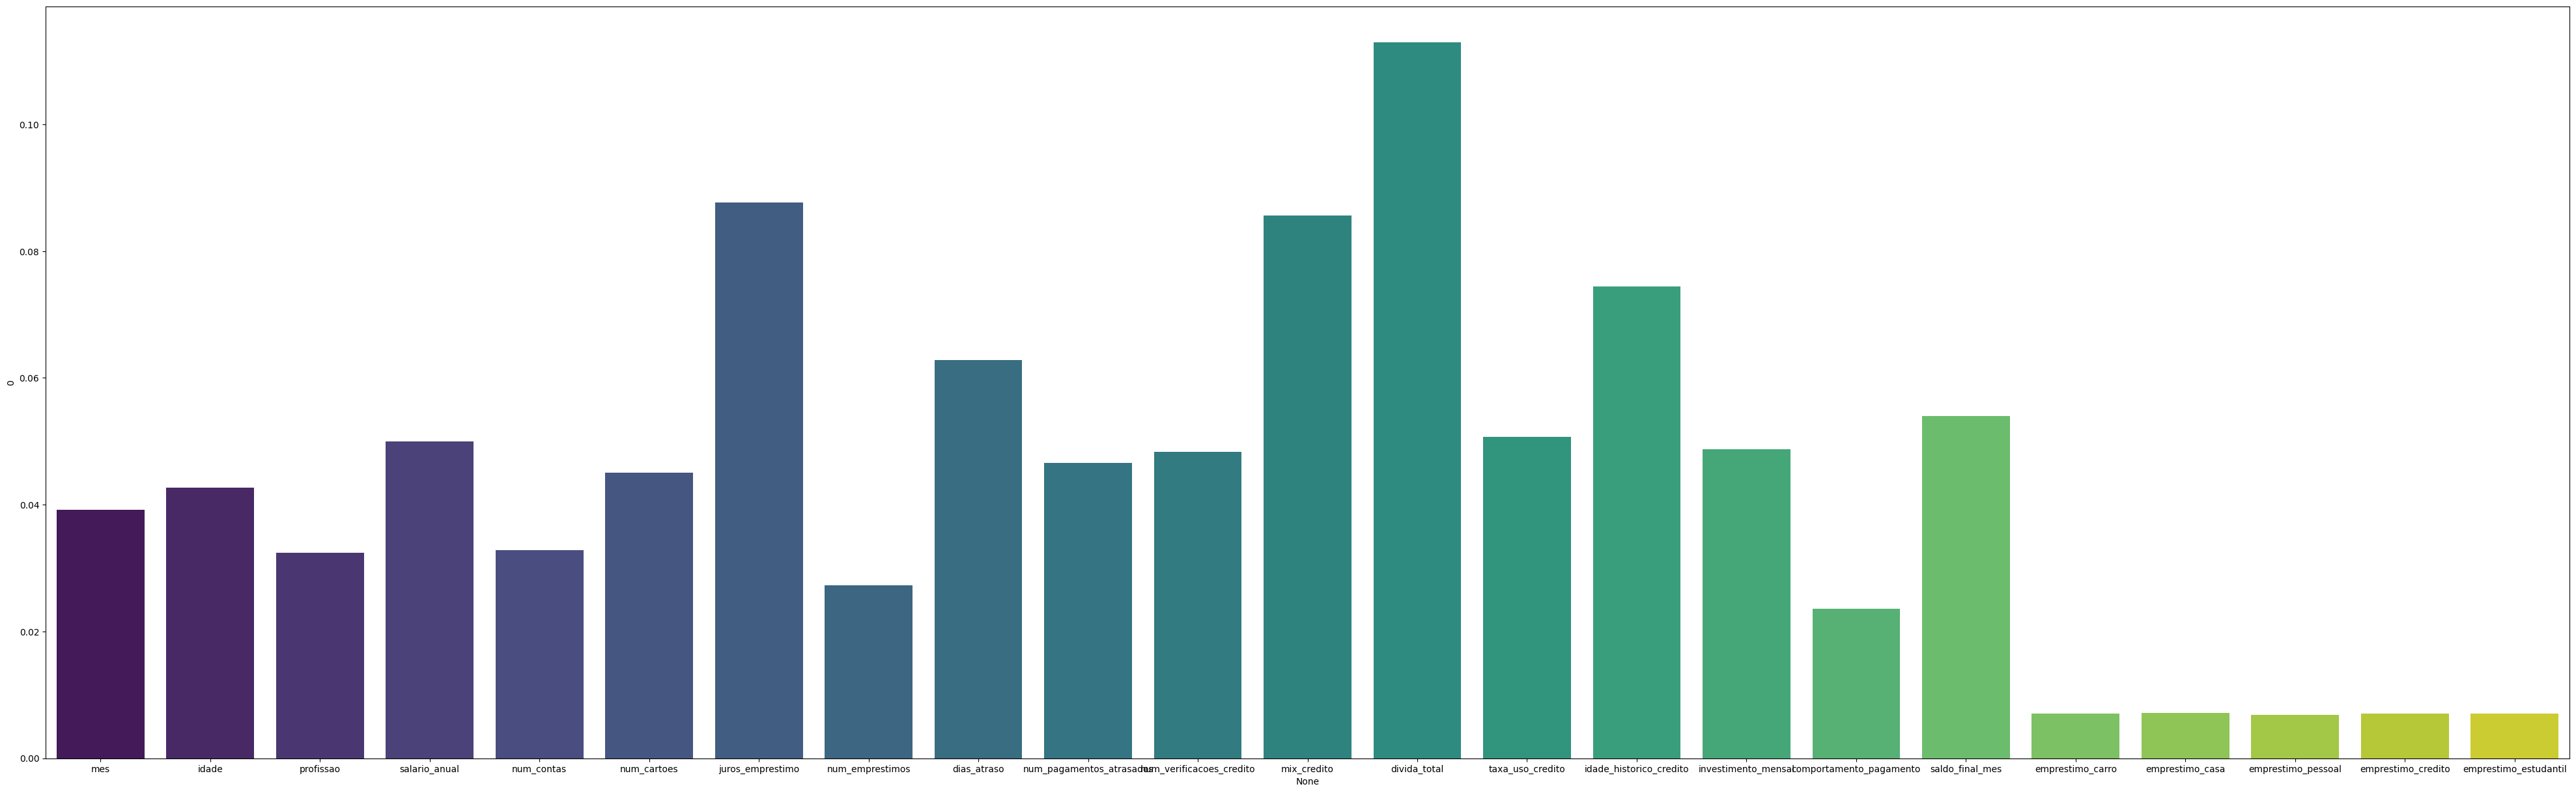

In [30]:
## Analise gráfica dos resultados do melhor modelo, nesse caso o Random Forest
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


importancia = pd.DataFrame(modelo_arvore_decisao.feature_importances_, x_treino.columns)

plt.figure(figsize=(50, 15))

sns.barplot(x=importancia.index, y=importancia[0], palette='viridis')

plt.show()

## Usar o melhor modelo para fazer previsão de novos clientes

In [31]:
# melhor modelo é o modelo_arvoredecisao

# importar os novos clientes para fazer a previsao
novos_clientes = pd.read_csv("novos_clientes.csv")

## Usar Label encoding para converter strings  em variáveis numéricas

# profissao -> convertes strings em numeros
novos_clientes["profissao"] = codificador_profissao.transform(novos_clientes["profissao"])

# mix_credito -> convertes strings em numeros
novos_clientes["mix_credito"] = codificador_mix_credito.transform(novos_clientes["mix_credito"])

# comportamento_pagamento -> convertes strings em numeros
novos_clientes["comportamento_pagamento"] = codificador_comportamento_pagamento.transform(novos_clientes["comportamento_pagamento"])

print(novos_clientes.info())

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   mes                       3 non-null      int64  
 1   idade                     3 non-null      float64
 2   profissao                 3 non-null      int64  
 3   salario_anual             3 non-null      float64
 4   num_contas                3 non-null      float64
 5   num_cartoes               3 non-null      float64
 6   juros_emprestimo          3 non-null      float64
 7   num_emprestimos           3 non-null      float64
 8   dias_atraso               3 non-null      float64
 9   num_pagamentos_atrasados  3 non-null      float64
 10  num_verificacoes_credito  3 non-null      float64
 11  mix_credito               3 non-null      int64  
 12  divida_total              3 non-null      float64
 13  taxa_uso_credito          3 non-null      float64
 14  idade_historico_credito  

In [32]:
# prever os scores de crédito dos novos clientes usando o modelo de árvore de decisão
previsao_arvore = modelo_arvore_decisao.predict(novos_clientes)

print(previsao_arvore)

['Poor' 'Poor' 'Standard']


In [33]:
# adicionar a coluna de previsao ao dataframe dos novos clientes

novos_clientes["score_credito_previsto"] = previsao_arvore

# caso queira salvar o arquivo com as previsões em csv
#novos_clientes.to_csv("novos_clientes.csv", index=False)

display(novos_clientes)

,mes,idade,profissao,salario_anual,num_contas,num_cartoes,juros_emprestimo,num_emprestimos,dias_atraso,num_pagamentos_atrasados,...,idade_historico_credito,investimento_mensal,comportamento_pagamento,saldo_final_mes,emprestimo_carro,emprestimo_casa,emprestimo_pessoal,emprestimo_credito,emprestimo_estudantil,score_credito_previsto
0,1,31.0,5,19300.340,6.0,7.0,17.0,5.0,52.0,19.0,...,218.0,44.50951,4,312.487689,1,1,0,0,0,Poor
1,4,32.0,0,12600.445,5.0,5.0,10.0,3.0,25.0,18.0,...,12.0,0.00000,5,300.994163,0,0,0,0,1,Poor
2,2,48.0,5,20787.690,8.0,6.0,14.0,7.0,24.0,14.0,...,215.0,0.00000,3,345.081577,0,1,0,1,0,Standard
